In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')
#matplotlib_inline.backend_inline.set_matplotlib_formats()

/tmp/ipykernel_5689/3585260749.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


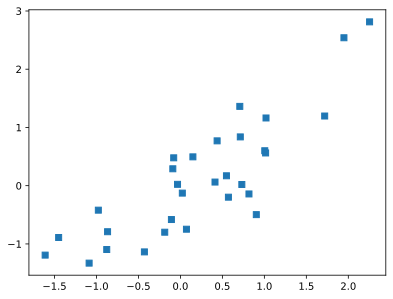

In [4]:
N = 30
x = torch.randn(N, 1)
y = x + torch.randn(N, 1)/2

plt.plot(x, y, 's')
plt.show()

In [5]:
## building model from pytorch

ANNreg = nn.Sequential(
    nn.Linear(1,1), #input
    nn.ReLU(), #activation
    nn.Linear(1,1) #output
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [7]:
lr = .05
loss_func = nn.MSELoss()

optimizer = torch.optim.SGD(ANNreg.parameters(), lr = lr)

In [8]:
# training model

num_of_epochs = 500
losses = np.zeros(num_of_epochs)

for epochi in range(num_of_epochs):
    y_hat = ANNreg(x)
    loss = loss_func(y_hat, y)
    losses[epochi] = loss
    #back propogation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

/tmp/ipykernel_5689/2647051112.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  losses[epochi] = loss


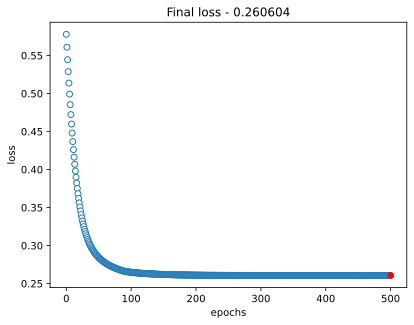

In [12]:
predictions = ANNreg(x)

testloss = (predictions-y).pow(2).mean()

plt.plot(losses, 'o', markerfacecolor='w', linewidth=.1)
plt.plot(num_of_epochs, testloss.detach(), 'ro')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Final loss - %g' %testloss.item())
plt.show()


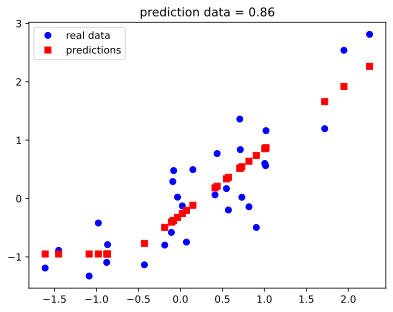

In [13]:
plt.plot(x,y,'bo', label='real data')
plt.plot(x, predictions.detach(),'rs', label='predictions')
plt.title(f'prediction data = {np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}')
plt.legend()
plt.show()